In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.5 MB/s eta 0:00:00


# Training

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load a model
model = YOLO("yolo11n.pt")  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data="brain-tumor.yaml", epochs=100, imgsz=640)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

# Saving the best weight

In [ ]:
import shutil
import os

# Kaynak dosya yolu
SOURCE_PATH = '/content/runs/detect/train/weights/best.pt'

# Hedef dosya yolu
DESTINATION_FOLDER = '/content/drive/MyDrive/YOLO_Tumor_Modeli'
DESTINATION_PATH = os.path.join(DESTINATION_FOLDER, 'best_brain_tumor_detector.pt')

# Hedef klasörü oluştur
os.makedirs(DESTINATION_FOLDER, exist_ok=True)

try:
    # Dosyayı kopyala
    shutil.copy(SOURCE_PATH, DESTINATION_PATH)
    print(f"Model başarıyla Drive'a kaydedildi: {DESTINATION_PATH}")
except FileNotFoundError:
    print("HATA: Kaynak dosya bulunamadı. Lütfen 'SOURCE_PATH' yolunu kontrol edin.")

Model başarıyla Drive'a kaydedildi: /content/drive/MyDrive/YOLO_Tumor_Modeli/best_brain_tumor_detector.pt


# Model Test


image 1/1 /content/drive/MyDrive/brain-tumor/images/val/val_1 (76).jpg: 640x640 1 negative, 16.1ms
Speed: 9.0ms preprocess, 16.1ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)


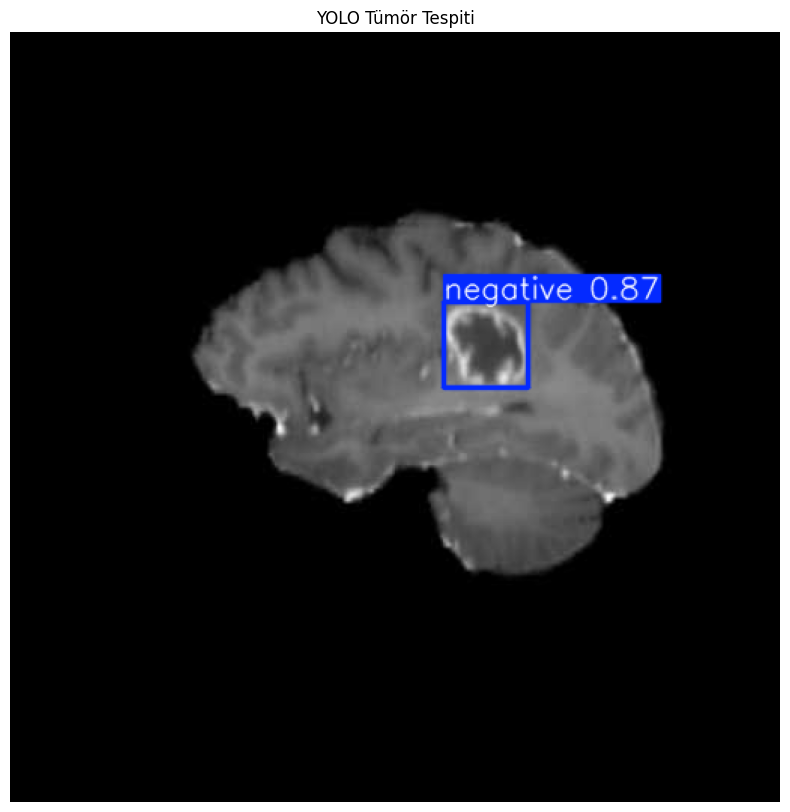

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# 1. En iyi modeli yükle
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Test edilecek bir resim yolu
test_image_path = '/content/drive/MyDrive/brain-tumor/images/val/val_1 (76).jpg'

# Eğer dosya adını bilmiyorsan, klasörden rastgele bir tane al:
# import glob
# test_image_path = glob.glob('/content/brain-tumor/images/val/*.jpg')[0]

# 3. Tahmin yap
results = model.predict(test_image_path, conf=0.25) # conf=0.25 güven eşiği

# 4. Sonucu Görselleştir
result_array = results[0].plot() # Çizilmiş hali (numpy array)
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(result_array, cv2.COLOR_BGR2RGB))
plt.title("YOLO Tümör Tespiti")
plt.axis('off')
plt.show()

# Pre-Segmentation Test

In [ ]:
# Tahmin sonuçlarından kutu koordinatlarını çekme
boxes = results[0].boxes.xyxy.cpu().numpy() # GPU'dan CPU'ya al ve numpy yap
confidences = results[0].boxes.conf.cpu().numpy()

if len(boxes) > 0:
    print(f"Tespit edilen tümör sayısı: {len(boxes)}")

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        conf = confidences[i]
        print(f"Tümör {i+1}: Güven Skoru: {conf:.2f}")
        print(f"Koordinatlar (MagicTouch Girdisi): [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")

        # run_segmentation(image, box_prompt=[x1, y1, x2, y2])
else:
    print("Hiç tümör tespit edilemedi.")

Tespit edilen tümör sayısı: 1
Tümör 1: Güven Skoru: 0.87
Koordinatlar (MagicTouch Girdisi): [288, 179, 344, 236]


# Segmentation (SAM)

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-eatjb3uu
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-eatjb3uu
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=e15856f5af7e0518052c7ae5d2573a93338163f016d2bee863981a3ec7265a4d
  Stored in directory: /tmp/pip-ephem-wheel-cache-z6dqmnwj/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [ ]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

class MagicTouchSegmentation:
    def __init__(self, checkpoint_path="sam_vit_b_01ec64.pth", model_type="vit_b"):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"MagicTouch (SAM) yükleniyor... ({device})")
        sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        sam.to(device=device)
        self.predictor = SamPredictor(sam)

    def predict(self, image, box):
        """
        image: Orijinal resim (numpy array)
        box: [x1, y1, x2, y2] formatında YOLO çıktısı
        """
        self.predictor.set_image(image)

        # Kutu formatını numpy array'e çevir
        input_box = np.array(box)

        # Maskeyi tahmin et
        masks, _, _ = self.predictor.predict(
            point_coords=None,
            point_labels=None,
            box=input_box[None, :], # Kutu bilgisini veriyoruz
            multimask_output=False,
        )
        # En iyi maskeyi döndür
        return masks[0]

# Modeli başlat
magic_touch = MagicTouchSegmentation()
print(f"Model yüklendi.")

MagicTouch (SAM) yükleniyor... (cuda)
Model yüklendi.


--> Tümör 1 tespit edildi. Güven: 0.87
--> Kutu: [        289       179.4      344.28      236.12]
--> MagicTouch (Segmentasyon) uygulanıyor...


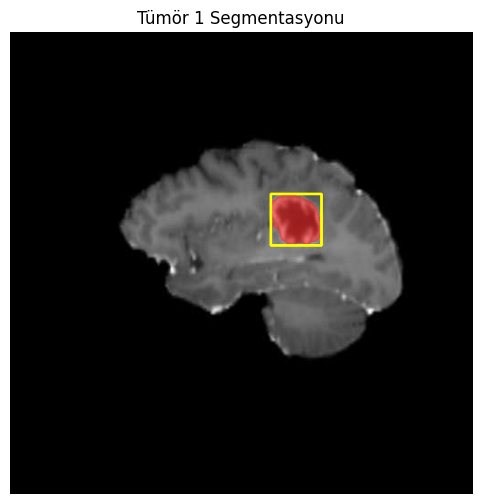

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Resmi tekrar yükleme (Görselleştirme için)
test_image_path = '/content/drive/MyDrive/brain-tumor/images/val/val_1 (76).jpg'
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. YOLO Sonuçlarını İşleme
boxes = results[0].boxes.xyxy.cpu().numpy()
confidences = results[0].boxes.conf.cpu().numpy()

plt.figure(figsize=(12, 6))

if len(boxes) > 0:
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box) # Koordinatları int yapma
        conf = confidences[i]

        print(f"--> Tümör {i+1} tespit edildi. Güven: {conf:.2f}")
        print(f"--> Kutu: {box}")

        # ---------------------------------------------------------
        # 3. MAGIC TOUCH ÇAĞRISI (Segmentasyon)
        # ---------------------------------------------------------
        print("--> MagicTouch (Segmentasyon) uygulanıyor...")

        # YOLO kutusunu verip maskeyi alma
        tumor_mask = magic_touch.predict(image, [x1, y1, x2, y2])

        # ---------------------------------------------------------
        # 4. GÖRSELLEŞTİRME
        # ---------------------------------------------------------

        # Orijinal resmin kopyasını alma
        overlay = image.copy()

        # Maskeyi kırmızı renkle boyama
        color = np.array([255, 0, 0]) # Kırmızı

        # Maskenin olduğu yerleri boyama (Alpha blending)
        overlay[tumor_mask] = overlay[tumor_mask] * 0.5 + color * 0.5

        # Sarı Kutu Çizme (YOLO Tespiti)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 255, 0), 2)

        plt.subplot(1, len(boxes), i+1)
        plt.imshow(overlay)
        plt.title(f"Tümör {i+1} Segmentasyonu")
        plt.axis('off')

    plt.show()
else:
    print("Hiç tümör tespit edilemedi.")

# GrabCut ve Magic Touch (SAM) Segmentation Karşılaştırması

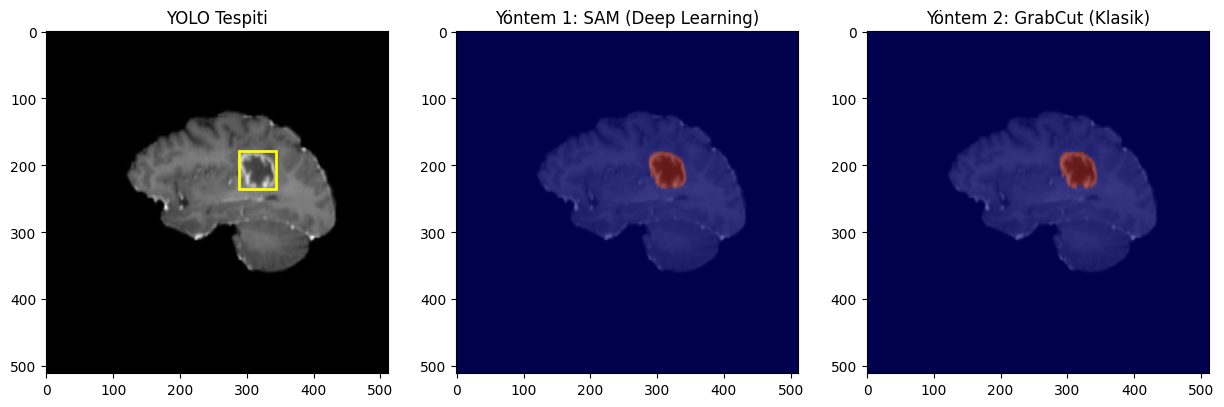

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def run_grabcut(image, box):
    """
    image: Orijinal resim
    box: [x, y, w, h] formatında (YOLO çıktısını buna çevireceğiz)
    """
    # 1. Maske ve geçici dizileri oluşturma
    mask = np.zeros(image.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    # 2. YOLO Kutusunu (x1, y1, x2, y2) -> (x, y, w, h) formatına çevirme
    x1, y1, x2, y2 = map(int, box)
    w = x2 - x1
    h = y2 - y1
    rect = (x1, y1, w, h)

    # 3. GrabCut Algoritmasını Çalıştırma (5 iterasyon)
    try:
        cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
    except Exception as e:
        print(f"GrabCut hatası: {e}")
        return np.zeros_like(mask) # Hata olursa boş maske dön

    # 4. Maskeyi temizleme (0 ve 2 arka plan, 1 ve 3 ön plan)
    mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')

    return mask2

boxes = results[0].boxes.xyxy.cpu().numpy()
confidences = results[0].boxes.conf.cpu().numpy()

# Test için resmi yükleme
test_image_path = '/content/drive/MyDrive/brain-tumor/images/val/val_1 (76).jpg'
img_bgr = cv2.imread(test_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

if len(boxes) > 0:
    # İlk bulunan kutuyu alma
    box = boxes[0] # [x1, y1, x2, y2]

    # --- YÖNTEM 1: MAGIC TOUCH (SAM) ---
    mask_sam = magic_touch.predict(img_rgb, box)

    # --- YÖNTEM 2: GRABCUT (KLASİK) ---
    mask_grabcut = run_grabcut(img_rgb, box)

    # --- KARŞILAŞTIRMA GÖRSELİ ---
    plt.figure(figsize=(15, 5))

    # Orijinal
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    x1, y1, x2, y2 = map(int, box)
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                      edgecolor='yellow', facecolor='none', lw=2))
    plt.title("YOLO Tespiti")

    # SAM Sonucu
    plt.subplot(1, 3, 2)
    plt.imshow(img_rgb)
    plt.imshow(mask_sam, alpha=0.6, cmap='jet') # Üstüne bindirme
    plt.title("Yöntem 1: SAM (Deep Learning)")

    # GrabCut Sonucu
    plt.subplot(1, 3, 3)
    plt.imshow(img_rgb)
    plt.imshow(mask_grabcut, alpha=0.6, cmap='jet') # Üstüne bindirme
    plt.title("Yöntem 2: GrabCut (Klasik)")

    plt.show()

else:
    print("Tümör bulunamadı.")

In [ ]:
import numpy as np

def calculate_clinical_metrics(mask, ground_truth_mask=None, pixel_spacing_mm=0.9375, slice_thickness_mm=3.0):
    """
    mask: SAM modelinden çıkan tahmin maskesi (0 ve 1)
    ground_truth_mask: Referans maske (Gerçek veya GrabCut sonucu)
    """

    # --- 1. ALAN VE HACİM HESABI ---
    pred_pixel_count = np.count_nonzero(mask)
    pixel_area_mm2 = pixel_spacing_mm * pixel_spacing_mm
    pred_area_cm2 = (pred_pixel_count * pixel_area_mm2) / 100.0
    pred_volume_cm3 = pred_area_cm2 * (slice_thickness_mm / 10.0)

    results = {
        "pixels": pred_pixel_count,
        "area_cm2": round(pred_area_cm2, 2),
        "estimated_vol_cm3": round(pred_volume_cm3, 2)
    }

    # --- 2. İSTATİSTİKSEL METRİKLER (MSE, MAE, mAP, Dice, IoU) ---
    if ground_truth_mask is not None:
        # Boolean dizileri 0 ve 1 integer'a çevirme
        pred = mask.astype(int)
        true = ground_truth_mask.astype(int)

        # Temel Bileşenler (Confusion Matrix)
        intersection = np.sum(pred * true) # TP (True Positive)
        total_pred = np.sum(pred)          # TP + FP
        total_true = np.sum(true)          # TP + FN

        # --- DICE & IoU ---
        union = total_pred + total_true - intersection
        iou = intersection / union if union > 0 else 0.0
        dice = (2.0 * intersection) / (total_pred + total_true) if (total_pred + total_true) > 0 else 0.0

        # --- MAPE (Hacimsel Sapma) ---
        if total_true > 0:
            error = abs(total_true - total_pred)
            mape = (error / total_true) * 100.0
        else:
            mape = 0.0 if total_pred == 0 else 100.0

        # --- MSE & MAE (Piksel Hatası) ---
        # Görüntüyü düzleştirip (flatten) tüm pikselleri karşılaştırıyoruz
        n_pixels = pred.size
        # Binary maskelerde (0,1) MSE ve MAE aynı sonucu verir: Hatalı Piksel Oranı
        mse = np.mean((true - pred) ** 2)
        mae = np.mean(np.abs(true - pred))

        # --- PRECISION & RECALL (mAP Bileşenleri) ---
        # Precision: Modelin "Tümör" dediklerinin ne kadarı gerçekten tümör?
        precision = intersection / total_pred if total_pred > 0 else 0.0

        # Recall: Gerçek tümörün ne kadarını yakaladık?
        recall = intersection / total_true if total_true > 0 else 0.0

        # F1 Score (Precision ve Recall'un harmonik ortalaması - Dice ile aynıdır ama ekledik)
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        # Sonuçları Sözlüğe Ekle
        results["iou"] = round(iou, 4)
        results["dice"] = round(dice, 4)
        results["mape"] = round(mape, 2)
        results["mse"] = round(mse, 5) # Çok küçük çıkabilir mazur görün lütfen Sinan hocam, hassasiyeti artırdık
        results["mae"] = round(mae, 5)
        results["precision"] = round(precision, 4)
        results["recall"] = round(recall, 4)
        results["f1"] = round(f1_score, 4)

    else:
        for metric in ["iou", "dice", "mape", "mse", "mae", "precision", "recall", "f1"]:
            results[metric] = "Referans Yok"

    return results

# Segmentasyon Performans Raporu

In [ ]:
# --- ANALİZ ÇAĞRISI (SAM vs GrabCut Referans Alarak) ---
metrics = calculate_clinical_metrics(mask=tumor_mask, ground_truth_mask=mask_grabcut)

print("\n" + "="*50)
print("       SEGMENTASYON PERFORMANS RAPORU      ")
print("="*50)

print(f"\n[1] KLİNİK ÖLÇÜMLER")
print(f"• Tümör Alanı           : {metrics['area_cm2']} cm²")
print(f"• Tahmini Hacim         : {metrics['estimated_vol_cm3']} cm³")

if metrics['mse'] != "Referans Yok":
    print(f"\n[2] DOĞRULUK VE ÖRTÜŞME METRİKLERİ")
    print(f"• Dice Skoru (F1 Score) : {metrics['dice']} (Segmentasyon başarısı)")
    print(f"• IoU (Jaccard Index)   : {metrics['iou']} (Alan örtüşmesi)")

    print(f"\n[3] HATA ANALİZİ (Error Metrics)")
    print(f"• MSE (Ort. Kare Hata)  : {metrics['mse']} (Piksel bazlı hata)")
    print(f"• MAE (Ort. Mutlak Hata): {metrics['mae']}")
    print(f"• MAPE (Hacim Sapması)  : %{metrics['mape']}")

    print(f"\n[4] mAP BİLEŞENLERİ (Tespit Performansı)")
    print(f"• Precision (Kesinlik)  : {metrics['precision']}")
    print(f"  (Modelin 'Tümör' dediği alanların doğruluk oranı)")
    print(f"• Recall (Duyarlılık)   : {metrics['recall']}")
    print(f"  (Gerçek tümörün ne kadarının tespit edildiği)")

    print("-" * 50)

    # Genel Yorum
    if metrics['dice'] > 0.85:
        print(">> GENEL DEĞERLENDİRME: ÇOK BAŞARILI MODEL")
    elif metrics['dice'] > 0.70:
        print(">> GENEL DEĞERLENDİRME: BAŞARILI (Klinik Kullanıma Uygun)")
    else:
        print(">> GENEL DEĞERLENDİRME: GELİŞTİRİLMEYE AÇIK")

print("="*50)


      SEGMENTASYON PERFORMANS RAPORU      

[1] KLİNİK ÖLÇÜMLER
• Tümör Alanı           : 21.94 cm²
• Tahmini Hacim         : 6.58 cm³

[2] DOĞRULUK VE ÖRTÜŞME METRİKLERİ
• Dice Skoru (F1 Score) : 0.9721 (Segmentasyon başarısı)
• IoU (Jaccard Index)   : 0.9457 (Alan örtüşmesi)

[3] HATA ANALİZİ (Error Metrics)
• MSE (Ort. Kare Hata)  : 0.00053 (Piksel bazlı hata)
• MAE (Ort. Mutlak Hata): 0.00053
• MAPE (Hacim Sapması)  : %0.52

[4] mAP BİLEŞENLERİ (Tespit Performansı)
• Precision (Kesinlik)  : 0.9696
  (Modelin 'Tümör' dediği alanların doğruluk oranı)
• Recall (Duyarlılık)   : 0.9746
  (Gerçek tümörün ne kadarının tespit edildiği)
--------------------------------------------------
>> GENEL DEĞERLENDİRME: ÇOK BAŞARILI MODEL


# Inference Scripti (Görselleştirme İçin)

Sistem başlatılıyor... (Cihaz: cuda)
YOLO Modeli yükleniyor: /content/runs/detect/train/weights/best.pt
MagicTouch (SAM) Modeli hazırlanıyor...
Sistem Hazır
Tespit edilen tümör sayısı: 1
Tumor #1 | Conf: 0.87 Alan: 21.94 cm2 | Hacim: ~6.58 cm3


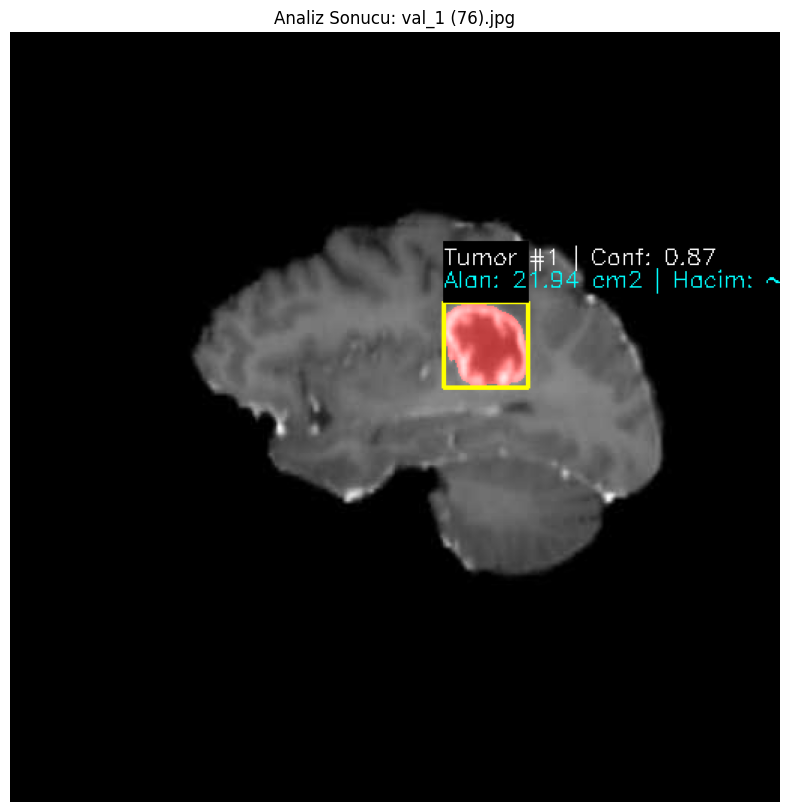

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor
import os

class TumorInferencePipeline:
    def __init__(self, yolo_model_path, sam_checkpoint_path="sam_vit_b_01ec64.pth", device=None):
        """
        Modelleri bir kez yükler ve hafızada tutar.
        """
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Sistem başlatılıyor... (Cihaz: {self.device})")

        # 1. YOLO Modelini Yükleme
        print(f"YOLO Modeli yükleniyor: {yolo_model_path}")
        self.yolo_model = YOLO(yolo_model_path)

        # 2. SAM (MagicTouch) Modelini Yükleme
        print("MagicTouch (SAM) Modeli hazırlanıyor...")
        sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint_path)
        sam.to(device=self.device)
        self.sam_predictor = SamPredictor(sam)
        print("Sistem Hazır")

    def process_image(self, image_path, pixel_spacing_mm=0.9375, slice_thickness_mm=3.0, conf_threshold=0.25):
        """
        Tek bir resim üzerinde tahmin yapar, ölçer ve görselleştirir.
        """
        # Resmi Okuma
        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            print(f"Hata: Resim bulunamadı -> {image_path}")
            return

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        vis_image = image_rgb.copy() # Üzerine çizim yapacağımız kopya (Orijinal değil)

        # 1. YOLO Tahmini (Object Detection)
        results = self.yolo_model.predict(image_rgb, conf=conf_threshold, verbose=False)
        boxes = results[0].boxes.xyxy.cpu().numpy()
        confidences = results[0].boxes.conf.cpu().numpy()

        if len(boxes) == 0:
            print(f"Sonuç: {os.path.basename(image_path)} içinde tümör tespit edilemedi.")
            self._show_result(vis_image, title="Tümör Tespit Edilemedi")
            return

        print(f"Tespit edilen tümör sayısı: {len(boxes)}")

        # 2. SAM İçin Resmi Hazırlama
        self.sam_predictor.set_image(image_rgb)

        # Her bir kutu için işlem yapma
        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box)
            confidence = confidences[i]

            # --- SEGMENTASYON (SAM) ---
            input_box = np.array([x1, y1, x2, y2])
            masks, _, _ = self.sam_predictor.predict(
                point_coords=None,
                point_labels=None,
                box=input_box[None, :],
                multimask_output=False,
            )
            mask = masks[0]

            # --- HESAPLAMALAR (Alan & Hacim) ---
            tumor_pixels = np.count_nonzero(mask)
            pixel_area_mm2 = pixel_spacing_mm ** 2
            area_cm2 = (tumor_pixels * pixel_area_mm2) / 100.0
            vol_cm3 = area_cm2 * (slice_thickness_mm / 10.0)

            # --- GÖRSELLEŞTİRME (Çizim) ---

            # A. Maskeyi Boyama (Yarı Saydam Kırmızı)
            color_mask = np.zeros_like(vis_image)
            color_mask[mask] = [255, 0, 0] # Kırmızı maske
            vis_image = cv2.addWeighted(vis_image, 1.0, color_mask, 0.5, 0) # 0.5 saydamlık

            # B. Kutuyu Çizme (Sarı)
            cv2.rectangle(vis_image, (x1, y1), (x2, y2), (255, 255, 0), 2)

            # C. Metinleri Yazma (Bilgi Kutusu)
            label_text = f"Tumor #{i+1} | Conf: {confidence:.2f}"
            stats_text = f"Alan: {area_cm2:.2f} cm2 | Hacim: ~{vol_cm3:.2f} cm3"

            # Etiket Arka Planı (Okunabilirlik için siyah şerit)
            cv2.rectangle(vis_image, (x1, y1-40), (x2, y1), (0, 0, 0), -1)
            cv2.putText(vis_image, label_text, (x1, y1 - 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            cv2.putText(vis_image, stats_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

            print(label_text,stats_text)

        # Sonucu Gösterme
        self._show_result(vis_image, title=f"Analiz Sonucu: {os.path.basename(image_path)}")

    def _show_result(self, image, title="Sonuç"):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.title(title)
        plt.axis('off')
        plt.show()

# 1. Dosya Yollarını Tanımlama
YOLO_PATH = '/content/runs/detect/train/weights/best.pt'
SAM_CHECKPOINT = 'sam_vit_b_01ec64.pth'

# 2. Pipeline'ı Başlatma (Sadece bir kere çalışır)
pipeline = TumorInferencePipeline(yolo_model_path=YOLO_PATH, sam_checkpoint_path=SAM_CHECKPOINT)

# 3. Resim test
TEST_RESMI = '/content/drive/MyDrive/brain-tumor/images/val/val_1 (76).jpg'

# Fonksiyonu çalıştır ve watch the magic happen
pipeline.process_image(TEST_RESMI)